# Part 3b: Automatic precision inference, profiling & tracing

In this notebook, we will explore:
    
- **Automatic precision inference**, which lets hls4ml automatically compute a conservative but layer-specific precision for each weight, bias, accumulator, and output tensor.
    
- **Profiling**, to visualise the numerical range of the weights and activations
    
- **Tracing**, to analyze per-layer outputs and verify accuracy is preserved.

Run either `1_getting_started/1a_train_keras.ipynb` or `1_getting_started/1b_train_pytorch.ipynb` first, then set `MODEL_TYPE` below.

In [10]:
MODEL_TYPE = 'pytorch'  # set to 'pytorch' if you used the PyTorch notebook

In [11]:
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
import plotting
import hls4ml
from sklearn.metrics import accuracy_score

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

%matplotlib inline

X_test = np.ascontiguousarray(np.load('../data/jet-tagging/X_test.npy'), dtype=np.float32)
y_test = np.load('../data/jet-tagging/y_test.npy')
classes = np.load('../data/jet-tagging/classes.npy', allow_pickle=True)

## Load the trained model

In [12]:
if MODEL_TYPE == 'keras':
    import tensorflow as tf

    trained_model = tf.keras.models.load_model('../models/keras_model_part1.h5')
    y_ref = trained_model.predict(X_test)

elif MODEL_TYPE == 'pytorch':
    import torch
    import torch.nn as nn

    class JetTagger(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(16, 64)
            self.fc2 = nn.Linear(64, 32)
            self.fc3 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 5)

        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return torch.softmax(self.output(x), dim=1)

    trained_model = JetTagger()
    trained_model.load_state_dict(torch.load('../models/pytorch_weights_part1.pt'))
    trained_model.eval()
    with torch.no_grad():
        y_ref = trained_model(torch.FloatTensor(X_test)).numpy()

print('Accuracy: {:.4f}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_ref, axis=1))))

Accuracy: 0.7634


## Make an hls4ml config with `granularity='name'`

In Part 1c we used `granularity='model'`, which applies the same configuration to every layer. Setting `granularity='name'` instead gives each layer its own config sub-dictionary, allowing us to tune the reuse factor, strategy, precision etc. per layer. 

When using `granularity='name'`, automatic precision inference is automatically enabled. The `auto` precision is computed conservatively: it guarantees no overflow or truncation based purely on the input bit-widths, without looking at the actual data distribution.

For example, the entry for `fc1` will look like:
```
LayerName:
    fc1:
        Trace:       False
        Precision:
            weight:  auto
            bias:    auto
            result:  auto
            accum:   auto
        ReuseFactor: 1
```

With `auto` precision:
- `weight` and `bias` default to the global model precision (`ap_fixed<16,6>`).
- `result` and `accum` are computed to be wide enough to hold the worst-case accumulation without overflow — these are often much wider than 16 bits. While ensuring no accuracy loss, it may come at the expense of resources.

This configuration is a useful starting point for manual tuning -- you can inspect the profiling plots below to decide which layers can safely use narrower types and accordingly update the config.

In [13]:
if MODEL_TYPE == 'keras':
    config = hls4ml.utils.config_from_keras_model(trained_model, granularity='name', backend='Vitis')
elif MODEL_TYPE == 'pytorch':
    config = hls4ml.utils.config_from_pytorch_model(trained_model, input_shape=(16,), granularity='name', backend='Vitis')

print('-----------------------------------')
plotting.print_dict(config)
print('-----------------------------------')

-----------------------------------
Model
  Precision
    default:         ap_fixed<16,6>
  ReuseFactor:       1
  ChannelsLastConversion:full
  TransposeOutputs:  False
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
PytorchModel:        JetTagger(
  (fc1): Linear(in_features=16, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=5, bias=True)
)
InputShape:          (16,)
LayerName
  x
    Trace:           False
    Precision
      result:        auto
  fc1
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
      accum:         auto
    ReuseFactor:     1
  relu
    Trace:           False
    Precision
      result:        auto
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  fc2
    Trace: 

## Profiling

The `hls4ml.model.profiling.numerical` function plots the distribution of weights and biases as a box-and-whisker chart. The **grey boxes** show the range representable with the data types set in the hls4ml config.

The rule of thumb:
- The grey box should cover the full whisker **to the right** (large values) — otherwise weights saturate or wrap around.
- It is acceptable for the box not to reach the left whisker (small values): those weights are simply rounded to zero, which is *often* harmless.

Providing data (here the first 1000 test samples for speed) also shows the same distributions at the **output of each layer**, which reveals whether the activation dynamic range is well-matched to the fixed-point type.

**Note:** if you find that the default 16-bit precision is too conservative for your model, the best solution is quantization-aware training (QAT) (see Part 2). Post-training, manual tuning (this notebook) is a useful alternative when retraining is not an option, but it requires more iterations and careful precision tuning.

Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 16]]
Layer name: relu, layer type: Activation, input shape: [[None, 64]]
Layer name: fc2, layer type: Dense, input shape: [[None, 64]]
Layer name: relu_1, layer type: Activation, input shape: [[None, 32]]
Layer name: fc3, layer type: Dense, input shape: [[None, 32]]
Layer name: relu_2, layer type: Activation, input shape: [[None, 32]]
Layer name: output, layer type: Dense, input shape: [[None, 32]]
Layer name: softmax, layer type: Softmax, input shape: [[None, 5]]
Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 16]]
Layer name: relu, layer type: Activation, input shape: [[None, 64]]
Layer name: fc2, layer type: Dense, input shape: [[None, 64]]
Layer name: relu_1, layer type: Activation, input shape: [[None, 32]]
Layer name: fc3, layer type: Dense, input shape: [[None, 32]]
Layer name: relu_2, layer type: Activation, input shape: [[None, 32]]
Layer name: ou

(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 None,
 <Figure size 640x480 with 1 Axes>)

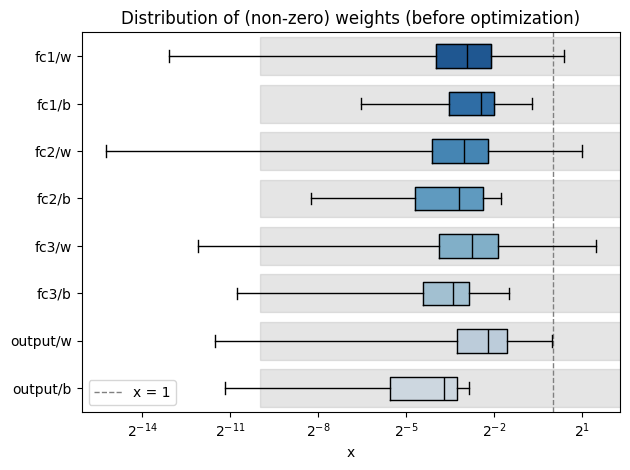

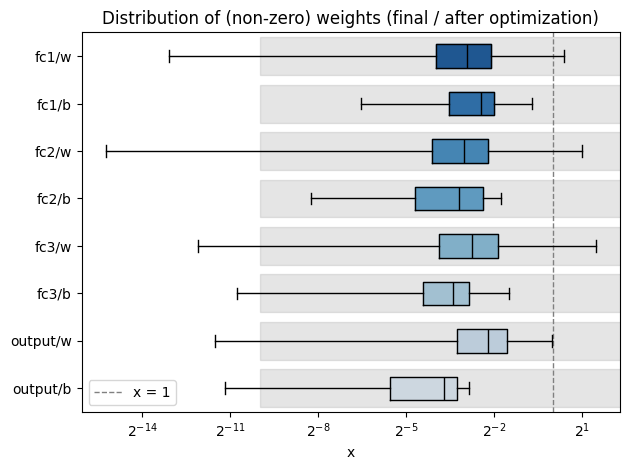

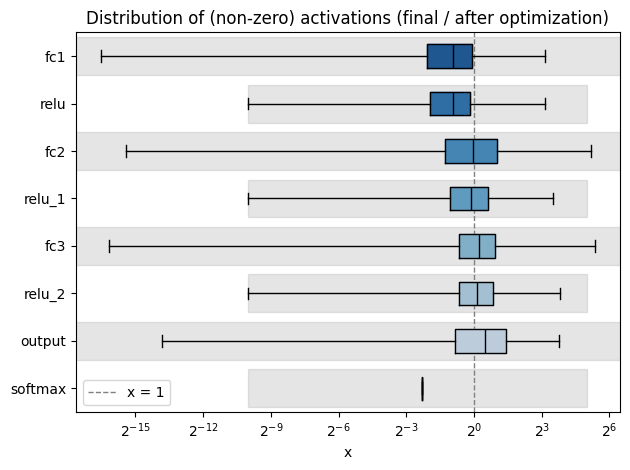

In [14]:
from hls4ml.model.profiling import numerical

for layer in config['LayerName'].keys():
    config['LayerName'][layer]['Trace'] = True

if MODEL_TYPE == 'keras':
    hls_model = hls4ml.converters.convert_from_keras_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_profiling_part3b',
        part='xcu200-fsgd2104-2-e',
    )
elif MODEL_TYPE == 'pytorch':
    hls_model = hls4ml.converters.convert_from_pytorch_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_profiling_part3b',
        part='xcu200-fsgd2104-2-e',
    )

numerical(model=trained_model, hls_model=hls_model, X=X_test[:1000])

## Customise precision

After inspecting the profiling plot, let's try narrowing the weight precision of `fc1` from 16 bits to 8 bits (`ap_fixed<8,2>` — 8 total bits, 2 integer bits). This reduces the multiplier width and can save significant LUT and DSP resources.

**Note on the output layer:** Using `auto` precision can produce an accumulator at the output of the last fully-connected layer that is wider than the softmax look-up tables can handle. We therefore manually cap it with `fixed<16,6,RND,SAT>`, which also enables rounding and saturation — important when narrowing any type that feeds into a non-linear function.

Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 16]]
Layer name: relu, layer type: Activation, input shape: [[None, 64]]
Layer name: fc2, layer type: Dense, input shape: [[None, 64]]
Layer name: relu_1, layer type: Activation, input shape: [[None, 32]]
Layer name: fc3, layer type: Dense, input shape: [[None, 32]]
Layer name: relu_2, layer type: Activation, input shape: [[None, 32]]
Layer name: output, layer type: Dense, input shape: [[None, 32]]
Layer name: softmax, layer type: Softmax, input shape: [[None, 5]]
Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 16]]
Layer name: relu, layer type: Activation, input shape: [[None, 64]]
Layer name: fc2, layer type: Dense, input shape: [[None, 64]]
Layer name: relu_1, layer type: Activation, input shape: [[None, 32]]
Layer name: fc3, layer type: Dense, input shape: [[None, 32]]
Layer name: relu_2, layer type: Activation, input shape: [[None, 32]]
Layer name: ou

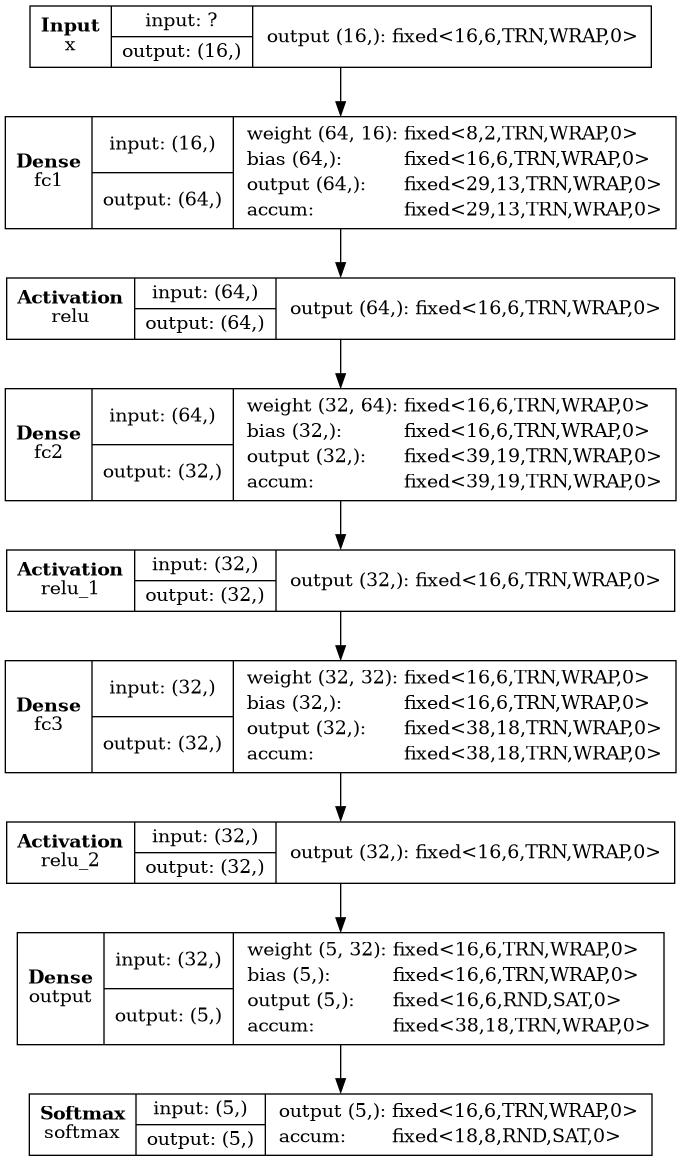

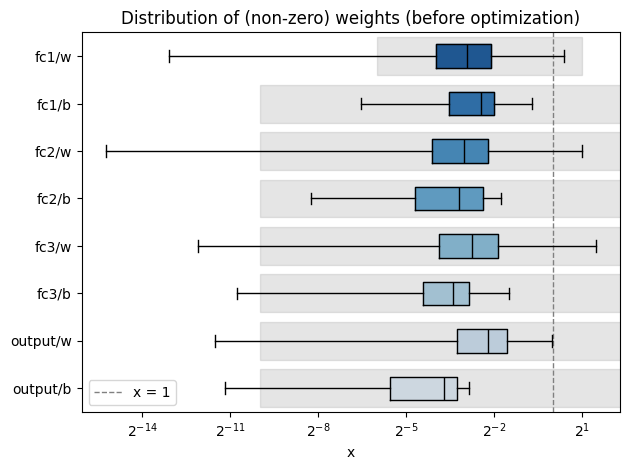

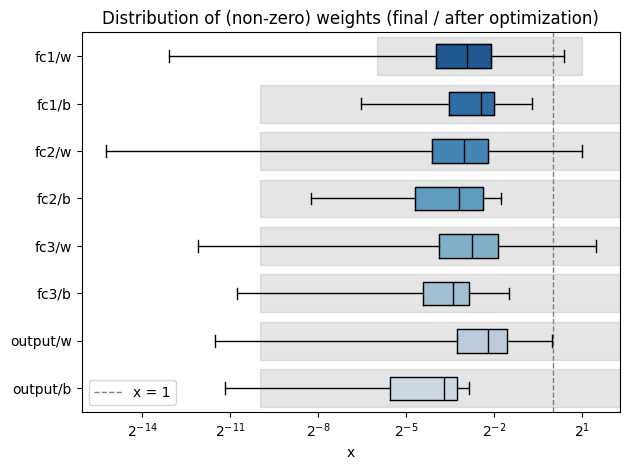

In [15]:
config['LayerName']['fc1']['Precision']['weight'] = 'ap_fixed<8,2>'
config['LayerName']['output']['Precision']['result'] = 'fixed<16,6,RND,SAT>'

if MODEL_TYPE == 'keras':
    hls_model = hls4ml.converters.convert_from_keras_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_profiling2_part3b',
        part='xcu200-fsgd2104-2-e',
    )
elif MODEL_TYPE == 'pytorch':
    hls_model = hls4ml.converters.convert_from_pytorch_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_profiling2_part3b',
        part='xcu200-fsgd2104-2-e',
    )

# Plot weight-only profile (no data) to see the updated precision boxes
numerical(model=trained_model, hls_model=hls_model)
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## Trace

When using customised per-layer precision, it is useful to collect the intermediate output of each layer and compare it between the original model and the hls4ml emulation. We enable this by setting `Trace = True` for every layer in the config, which we already did above.

Re-convert with all traces enabled so the compiled model will record layer outputs.

In [16]:
for layer in config['LayerName'].keys():
    config['LayerName'][layer]['Trace'] = True

if MODEL_TYPE == 'keras':
    hls_model = hls4ml.converters.convert_from_keras_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_tracing_part3b',
        part='xcu200-fsgd2104-2-e',
    )
elif MODEL_TYPE == 'pytorch':
    hls_model = hls4ml.converters.convert_from_pytorch_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_tracing_part3b',
        part='xcu200-fsgd2104-2-e',
    )

Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 16]]
Layer name: relu, layer type: Activation, input shape: [[None, 64]]
Layer name: fc2, layer type: Dense, input shape: [[None, 64]]
Layer name: relu_1, layer type: Activation, input shape: [[None, 32]]
Layer name: fc3, layer type: Dense, input shape: [[None, 32]]
Layer name: relu_2, layer type: Activation, input shape: [[None, 32]]
Layer name: output, layer type: Dense, input shape: [[None, 32]]
Layer name: softmax, layer type: Softmax, input shape: [[None, 5]]


## Compile, trace, predict

Compile the hls4ml model and call `hls_model.trace` instead of `hls_model.predict`. This returns both the final predictions **and** a dictionary of intermediate layer outputs — one array per layer, keyed by layer name.

We collect the same dictionary from the original model for comparison. We only trace the first 1000 samples since tracing is slower than a plain forward pass.

In [17]:
hls_model.compile()
hls4ml_pred, hls4ml_trace = hls_model.trace(X_test[:1000])
y_hls = hls_model.predict(X_test)

if MODEL_TYPE == 'keras':
    from hls4ml.model.profiling import get_ymodel_keras

    ref_trace = get_ymodel_keras(trained_model, X_test[:1000])

elif MODEL_TYPE == 'pytorch':
    ref_trace = {}
    hooks = []

    def make_hook(name):
        def hook(module, inp, out):
            if isinstance(out, torch.Tensor):
                ref_trace[name] = out.detach().numpy()

        return hook

    for name, module in trained_model.named_modules():
        if name:
            hooks.append(module.register_forward_hook(make_hook(name)))

    trained_model.eval()
    with torch.no_grad():
        trained_model(torch.FloatTensor(X_test[:1000]))

    for h in hooks:
        h.remove()

Recompiling myproject with tracing


## Inspect

We can now print, plot, or otherwise compare the output of each layer between the original model and the hls4ml fixed-point emulation. This makes it easy to spot which layer first deviates — a sign that the precision there is too narrow.

Let's print the first-layer output for the very first test sample.

In [18]:
layer_name = 'fc1'
print(f"Original model layer '{layer_name}', first sample:")
print(ref_trace[layer_name][0])
print(f"hls4ml layer '{layer_name}', first sample:")
print(hls4ml_trace[layer_name][0])

Original model layer 'fc1', first sample:
[ 1.8732634   0.6012758   0.61762494 -1.8676424  -0.39952275  0.79607904
  0.33161694  0.636077    1.0178099  -0.02789657  1.768362    0.83867586
  1.2157506  -0.5811417   0.86471206  0.7562681   0.8484857  -0.0878154
  1.050578   -1.9246103   0.11906655  0.31197006 -1.609439    0.29832542
 -1.137877    0.82296646 -0.16455714 -0.00820914 -1.4536105   2.321613
 -1.0997739  -0.22498694 -0.9081731  -0.01633054 -0.05274308  0.0620187
 -0.14696653 -0.23968989  0.7872665   1.3343713   0.55894315  1.0516714
  0.7641039   0.10026775 -1.6532655   0.5247789   1.7431386  -1.0713501
  0.77045166  0.6235896  -0.7835622  -1.7531755  -0.06336461 -0.97728425
  0.62436646 -1.2661806  -0.85257924  0.44254434  1.1288879  -0.6490147
  0.38047433  0.6856278   0.4308725   0.7551757 ]
hls4ml layer 'fc1', first sample:
[ 1.8492432   0.54504395  0.568573   -1.9100647  -0.43049622  0.79200745
  0.32582092  0.622818    1.005539   -0.04640198  1.7649689   0.8252106
  1.14

## Compare

Let's see whether the 8-bit weight precision on `fc1` has degraded overall accuracy.

pytorch Accuracy:  0.7634
hls4ml Accuracy: 0.7622


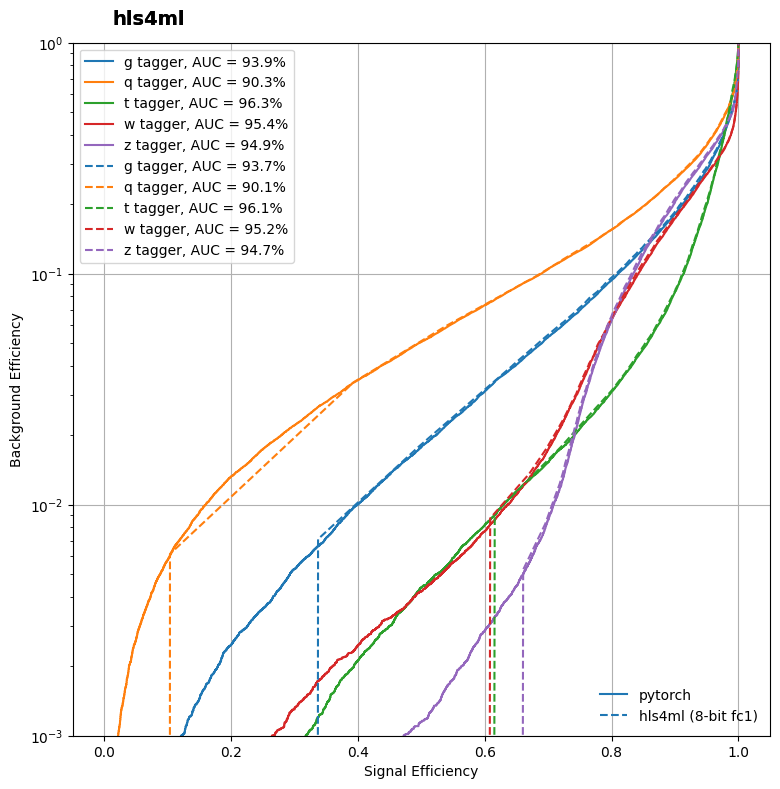

In [19]:
print('{} Accuracy:  {:.4f}'.format(MODEL_TYPE, accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_ref, axis=1))))
print('hls4ml Accuracy: {:.4f}'.format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_ref, list(classes))
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_hls, list(classes), linestyle='--')

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
leg = Legend(ax, lines, labels=[MODEL_TYPE, 'hls4ml (8-bit fc1)'], loc='lower right', frameon=False)
ax.add_artist(leg)

## Further reading

For more details, see: Schulte, Ramhorst, Sun et al., "hls4ml: A Flexible, Open-Source Platform for Deep Learning Acceleration on Reconfigurable Hardware", ACM Trans. Reconfigurable Technol. Syst. (2026), [doi:10.1145/3801979](https://dl.acm.org/doi/abs/10.1145/3801979)